شروع آموزش مدل...
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 615.5967 - mae: 23.3642 - rmse: 24.8112 - val_loss: 661.7014 - val_mae: 24.4588 - val_rmse: 25.7236
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 598.7803 - mae: 22.9784 - rmse: 24.4700 - val_loss: 645.8403 - val_mae: 24.1090 - val_rmse: 25.4134
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 583.1792 - mae: 22.5891 - rmse: 24.1491 - val_loss: 629.5537 - val_mae: 23.7411 - val_rmse: 25.0909
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 566.2139 - mae: 22.1758 - rmse: 23.7952 - val_loss: 612.3562 - val_mae: 23.3367 - val_rmse: 24.7458
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 548.1939 - mae: 21.7045 - rmse: 23.4135 - val_loss: 592.2185 - val_mae: 22.8572 - val_rmse: 24.3355
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 526.7836 - mae: 21.1363 - rmse: 22.9518 - val_loss: 568.5235 - val_mae: 22.2778 - val_rmse: 23.8437
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━

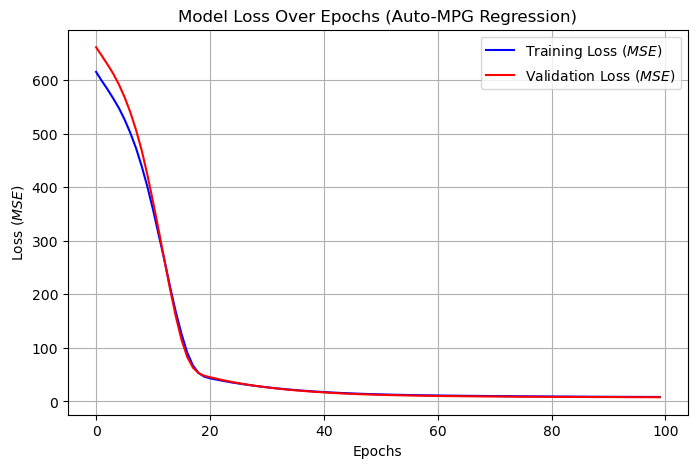

In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. بارگذاری داده 
df = pd.read_csv('auto-mpg.csv')

# پاک‌سازی داده‌ها:
if 'car name' in df.columns:
    df = df.drop('car name', axis=1)

df = df.replace('?', np.nan)

df = df.dropna()

df = df.astype(float)

# جداسازی ویژگی‌ها
X = df.drop('mpg', axis=1)
y = df['mpg']

# تقسیم به داده‌های آموزش و آزمون
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# استانداردسازی داده‌ها (جلوگیری از نشت داده)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. ساخت مدل شبکه عصبی برای رگرسیون
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),  # لایه ورودی مجزا
    layers.Dense(64, activation='relu'),             # لایه مخفی اول
    layers.Dense(32, activation='relu'),             # لایه مخفی دوم
    layers.Dense(1)                                  # لایه خروجی
])

# 3. کامپایل مدل
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae', keras.metrics.RootMeanSquaredError(name='rmse')]
)

# 4. آموزش مدل
print("شروع آموزش مدل...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 5. ارزیابی مدل
loss, mae, rmse = model.evaluate(X_test_scaled, y_test, verbose=1)
print("\nارزیابی مدل روی داده‌های تست:")
print(f"Loss (MSE): {loss:.4f}")
print(f"MAE: {mae:.2f}")
print(f"rmse: {rmse:.2f}")

# 6. رسم نمودار روند آموزش
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss ($MSE$)', color='blue')
plt.plot(val_loss, label='Validation Loss ($MSE$)', color='red')
plt.title('Model Loss Over Epochs (Auto-MPG Regression)')
plt.xlabel('Epochs')
plt.ylabel('Loss ($MSE$)')
plt.legend()
plt.grid(True)
plt.show()
